# Pathway analysis

In [1]:
# ── Setup ──────────────────────────────────────────────────────────────────
import sys
sys.path.append('../../scripts')

import numpy as np
import scanpy as sc
import anndata as ad
import pandas as pd
import os
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
import decoupler as dc
import hotspot

from cellina import Cellina as CellinaModel
from utils import set_seed
from train_loo import preprocess_adata
from plotting import plot_pathway_activity, plot_custom_umap
from helpers import (
    _normalize_counts, safe_log2_fold_change, compute_correlations, subsample_adata,
    compute_microenv_logfc, _pw_concordant_series, _all_de_series,
    build_perturbation_dict, cf_logfc,
)


In [2]:
set_seed(0)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 16
plt.rcParams['figure.dpi'] = 100

slide_id = 'crc_210'
labels_key  = 'coarse_type'
domains_key = 'typ_clean'
batch_key   = 'sid'
fig_save_path = '../../figures/application'

# ── Load Part 1 outputs ────────────────────────────────────────────────────
adata = sc.read_h5ad("output/adata_with_microenv.h5ad")
print(f"Loaded adata: {adata}")

with open("output/hotspot.pkl", "rb") as _f:
    hs = pickle.load(_f)
print("Loaded hotspot object")

with open("output/results.pkl", "rb") as _f:
    results = pickle.load(_f)
print(f"Loaded results dict with keys: {list(results.keys())}")

model_base_path = f"./{slide_id}"
# Pick the most recently saved checkpoint (avoids stale checkpoints from other model classes)
checkpoint_name = max(os.listdir(model_base_path), key=lambda d: os.path.getmtime(f"{model_base_path}/{d}"))
model = CellinaModel.load(
    f"{model_base_path}/{checkpoint_name}",
    adata=adata,
)
print("Loaded model")

adata.obsm['recon_x'] = model.get_normalized_expression(adata=adata, batch_size=4096, library_size=1e4)
print("Computed recon_x")
microenvironments = [m for m in adata.obs['microenvironment'].unique() if 'CRC' in str(m)]
print(f"Microenvironments: {microenvironments}")

Loaded adata: AnnData object with n_obs × n_vars = 552241 × 2000
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Dash', 'ISH.concentration', 'Panel', 'Run_Tissue_name', 'Run_name', 'assay_type', 'dualfiles', 'tissue', 'version', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'fals

INFO: Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
2026-06-03 20:39:51 | [INFO] Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


Loaded results dict with keys: ['Endothelial', 'Epithelial', 'Fibroblast', 'Myeloid', 'T_cell']
INFO     File ./crc_210/epoch=25-step=10950-vae_loss_validation=304.0638732910156/model.pt already downloaded      


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = to

INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        
Loaded model
Computed recon_x
Microenvironments: ['CRC3', 'CRC2', 'CRC1', 'CRC4']


## Counterfactual fibroblast UMAP

In [3]:
# subsample_adata imported from helpers (cell 1)


In [4]:
# Get cellina spatial for non CRC cells
adata_list = []
select_ct = "Fibroblast"
adata_fib = results[select_ct].copy()
control_mask = adata_fib.obs[domains_key].astype(str).str.contains('REF')
X = adata_fib.obsm['recon_x'][control_mask.values, :]
X = np.log1p(X)
adata_control = ad.AnnData(X=X, 
                           obs=adata_fib.obs[control_mask])
#adata_list.append(subsample_adata(adata_control, fraction=0.1, random_state=0))
adata_list.append(subsample_adata(adata_control, fraction=1, random_state=0))

for microenv in microenvironments:
    # Get real latents for cells in this microenvironment
    real_mask = adata.obs['microenvironment'].astype(str).str.contains(microenv) & (adata.obs[labels_key].astype(str) == select_ct)
    X = adata.obsm['recon_x'][real_mask.values, :]
    X = np.log1p(X)
    obs=adata.obs[real_mask]
    adata_real = ad.AnnData(X=X, obs=obs)
    adata_real.obs['microenvironment'] = microenv
    #adata_list.append(subsample_adata(adata_real, fraction=0.2, random_state=0))
    adata_list.append(subsample_adata(adata_real, fraction=1., random_state=0))
    
    # Get counterfactual latents for this microenvironment
    X = adata_fib.uns[f'counterfactual_x_{microenv}']
    X = np.log1p(X)
    obs = adata_fib.obs[~adata_fib.obs[domains_key].str.contains('CRC')]
    obs['microenvironment'] = f"{microenv}_counterfactual"
    adata_cf = ad.AnnData(X=X, obs=obs)
    #adata_list.append(subsample_adata(adata_cf, fraction=0.1, random_state=0))
    adata_list.append(subsample_adata(adata_cf, fraction=1., random_state=0))

/tmp/ipykernel_1036564/1424085326.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  obs['microenvironment'] = f"{microenv}_counterfactual"
/tmp/ipykernel_1036564/1424085326.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  obs['microenvironment'] = f"{microenv}_counterfactual"
/tmp/ipykernel_1036564/1424085326.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: 

In [5]:
# Merge all adatas in list
adata_fib_merged = ad.concat(adata_list, join='outer')
adata_fib_merged.obs_names_make_unique()

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [6]:
sc.pp.pca(adata_fib_merged, n_comps=50)
sc.pp.neighbors(adata_fib_merged, n_pcs=20)
sc.tl.umap(adata_fib_merged)

In [7]:
# rename REF, TVA to control
#adata_fib_merged.obs['microenvironment'] = adata_fib_merged.obs['microenvironment'].replace({'REF': 'Control', 'TVA': 'Control'})
adata_fib_merged.obs['domain'] = adata_fib_merged.obs['microenvironment']
adata_fib_merged.obs['domain'] = adata_fib_merged.obs['domain'].replace({'210_REF': 'Control'})
adata_fib_merged.obs['domain'] = adata_fib_merged.obs['domain'].astype('category')

In [8]:
palette = {
    'CRC1': "#580803",
    'CRC1 CF': '#F4A582',  # lighter version
    'CRC2': "#011080",
    'CRC2 CF': '#92C5DE',  # lighter version
}

In [9]:
adata_fib_merged.obs['domain'].value_counts()

domain
CRC1                   34458
CRC1_counterfactual     7006
CRC2_counterfactual     7006
CRC4_counterfactual     7006
CRC3_counterfactual     7006
CRC2                    4213
Control                 2456
CRC4                    1733
CRC3                    1125
Name: count, dtype: int64

/tmp/ipykernel_1036564/1030890215.py:7: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_sub.obs['domain_short'] = adata_sub.obs['domain'].replace({
... storing 'cell_id' as categorical
... storing 'cell' as categorical
... storing 'microenvironment' as categorical


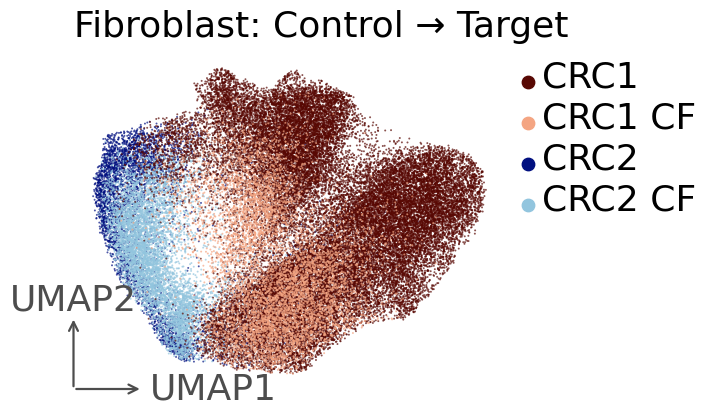

../../figures/application/crc_210_umap_cf_Fibroblasts.svg


In [10]:
import matplotlib.pyplot as plt
import scanpy as sc

domains = ['CRC1', 'CRC1_counterfactual', 'CRC2', 'CRC2_counterfactual'] # 'Control',
adata_sub = adata_fib_merged[adata_fib_merged.obs['domain'].isin(domains)].copy()

adata_sub.obs['domain_short'] = adata_sub.obs['domain'].replace({
    'Control': 'Control',
    'CRC1': 'CRC1',
    'CRC1_counterfactual': 'CRC1 CF',
    'CRC2': 'CRC2',
    'CRC2_counterfactual': 'CRC2 CF'
})

ax = sc.pl.umap(
    adata_sub,
    color='domain_short',
    palette=palette,
    show=False,
    title='',
    size=8,
    alpha=0.7,
    frameon=False,
)

fig = ax.figure
fig.set_size_inches(6, 4)
ax.set_position([0.05, 0.08, 0.72, 0.84])

ax.set_title(
    f"{select_ct}: Control → Target",
    fontsize=26,
    # fontweight='bold',
    pad=12,
    loc='left',
)

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([])
ax.set_yticks([])

arrow_kw = dict(arrowstyle='->', color='0.3', lw=1.6)
x0, y0 = ax.get_xlim()[0], ax.get_ylim()[0]
offset = (ax.get_xlim()[1] - x0) * 0.08
ax.annotate('', xy=(x0 + offset * 2, y0), xytext=(x0, y0),
            arrowprops=arrow_kw, annotation_clip=False)
ax.annotate('', xy=(x0, y0 + offset * 2), xytext=(x0, y0),
            arrowprops=arrow_kw, annotation_clip=False)
ax.text(x0 + offset * 2.2, y0, 'UMAP1', fontsize=26, color='0.3', va='center')
ax.text(x0, y0 + offset * 2.2, 'UMAP2', fontsize=26, color='0.3', ha='center')

legend = ax.get_legend()
if legend is not None:
    legend.set_title('')
    legend.get_frame().set_linewidth(0)
    legend.get_frame().set_alpha(0)
    for text in legend.get_texts():
        text.set_fontsize(26)
    for handle in legend.legend_handles:
        handle.set_sizes([80])
    legend.set_bbox_to_anchor((1.02, 1))
    legend.set_loc('upper left')

for coll in ax.collections:
    coll.set_rasterized(True)

plt.show()

fig.savefig(
    f"{fig_save_path}/{slide_id}_umap_cf_Fibroblasts.svg",
    dpi=300,
    bbox_inches='tight',
    transparent=True,
)
print(f"{fig_save_path}/{slide_id}_umap_cf_Fibroblasts.svg")

In [11]:
f"{select_ct}: Control → Target"

'Fibroblast: Control → Target'

### Pathways

In [12]:
# plot_pathway_activity imported from plotting in cell 1


In [13]:
# Get module x gene matrix
gene_modules = hs.modules
gene_c = hs.results[['C']]
df = gene_c.join(gene_modules.rename("Module"))
df = df[~(df["Module"].isna()) & (df["Module"] != -1.0)] # NOTE: drop NaNs and -1 (unassigned genes)
module_gene_matrix = df.pivot_table(index="Module", columns=df.index, values="C", fill_value=0)

In [14]:
hs.results[['C']]

,C
Gene,
CXCL8,0.221253
COL1A1,0.289536
IGHG1,0.156309
MMP3,0.115259
MMP1,0.133393
...,...
RAD54B,-0.000364
OR13J1,-0.000286
NLRP2B,-0.000289


In [15]:
df['Module'].unique()

array([2., 1., 3., 4.])

In [16]:
module_gene_matrix

Gene,A2M,ABCA1,ABCB1,ABHD2,ABI3,ACAN,ACP5,ACTA2,ACTG2,ADAM19,...,WNT4,WNT5A,XDH,ZBTB16,ZC3H12A,ZCCHC24,ZEB1,ZEB2,ZFAND2A,ZFP36
Module,,,,,,,,,,,,,,,,,,,,,
1.0,0.087742,0.007361,0.000000,0.000000,0.005046,0.005019,0.015255,0.070648,0.030681,0.013756,...,0.026704,0.016907,0.000000,0.011909,0.000000,0.010866,0.005073,0.016506,0.000000,0.000000
2.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.064154
3.0,0.000000,0.000000,0.000000,0.025757,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.024965,0.000000,0.022659,0.000000,0.000000,0.000000,0.011684,0.000000
4.0,0.000000,0.000000,0.019702,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [17]:
pw_progeny = dc.op.progeny(organism="human")
pw_hallmark = dc.op.hallmark(organism="human")

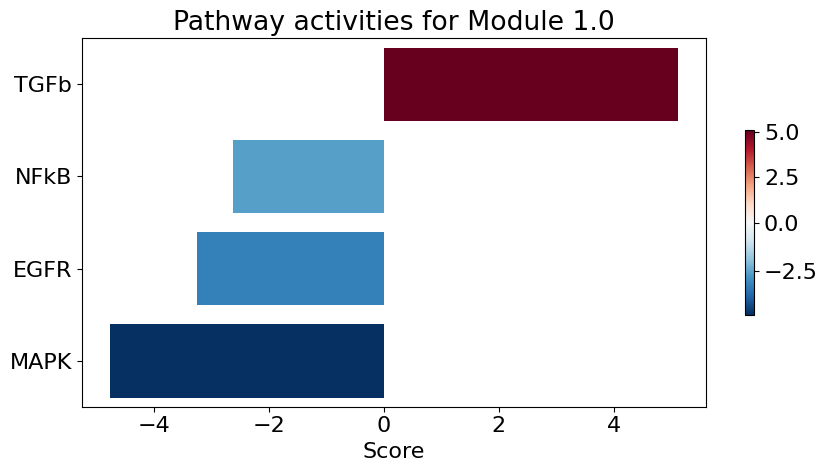

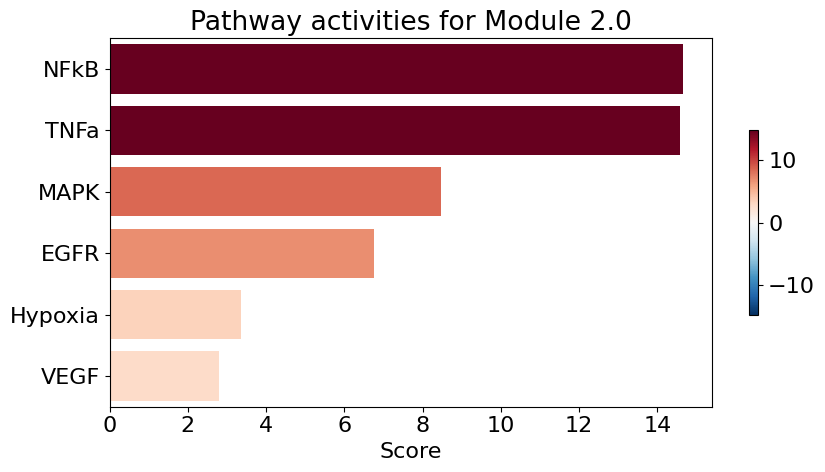

In [18]:
# Progeny pathway activity
pw_acts_progeny, pw_padj_progeny = dc.mt.ulm(data=module_gene_matrix, net=pw_progeny)
plot_pathway_activity(pw_acts_progeny, pw_padj_progeny, alpha=0.05)

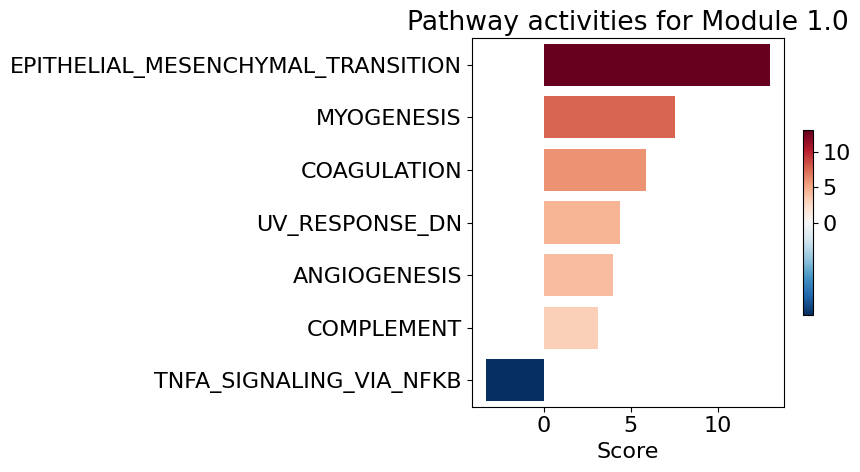

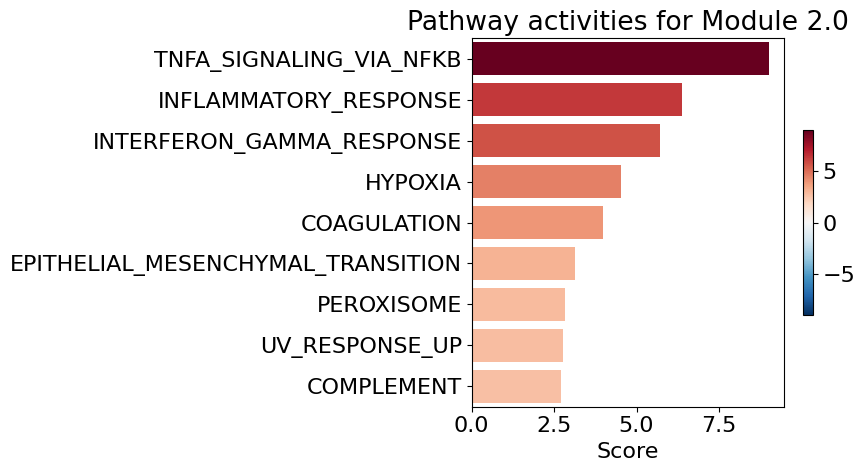

In [19]:
# Hallmark pathway activity
pw_acts_hallmark, pw_padj_hallmark = dc.mt.ulm(data=module_gene_matrix, net=pw_hallmark)
plot_pathway_activity(pw_acts_hallmark, pw_padj_hallmark, alpha=0.05)

In [20]:
pw_acts_joint = pw_acts_progeny.merge(pw_acts_hallmark, left_index=True, right_index=True).T
pw_padj_joint = pw_padj_progeny.merge(pw_padj_hallmark, left_index=True, right_index=True).T


In [21]:
# to long
pw_acts_long = pw_acts_joint.reset_index().melt(id_vars='index', var_name='Module', value_name='Activity').sort_values(['index', 'Module'])
pw_padj_long = pw_padj_joint.reset_index().melt(id_vars='index', var_name='Module', value_name='padj').sort_values(['index', 'Module'])
pw_joint = pw_acts_long.merge(pw_padj_long, on=['index', 'Module'])

In [22]:
# rename index to Pathway
pw_joint = pw_joint.rename(columns={'index': 'Pathway'})


In [23]:
pw_joint['Module'] = [f"CRC{int(float(col.split()[-1]))}" for col in pw_joint['Module']]

In [24]:
# rename index value 'EPITHELIAL_MESENCHYMAL_TRANSITION' to EMT
pw_joint['Pathway'] = pw_joint['Pathway'].str.replace('EPITHELIAL_MESENCHYMAL_TRANSITION', 'EMT')

In [25]:
pw_joint

,Pathway,Module,Activity,padj
0,ADIPOGENESIS,CRC1,1.310260,0.430924
1,ADIPOGENESIS,CRC2,0.088048,0.978736
2,ADIPOGENESIS,CRC3,-0.583821,0.829562
3,ADIPOGENESIS,CRC4,-0.755357,0.845303
4,ALLOGRAFT_REJECTION,CRC1,-0.346092,0.847619
...,...,...,...,...
223,XENOBIOTIC_METABOLISM,CRC4,0.252398,0.944810
224,p53,CRC1,0.883692,0.659881
225,p53,CRC2,1.891884,0.117589
226,p53,CRC3,1.413650,0.422128


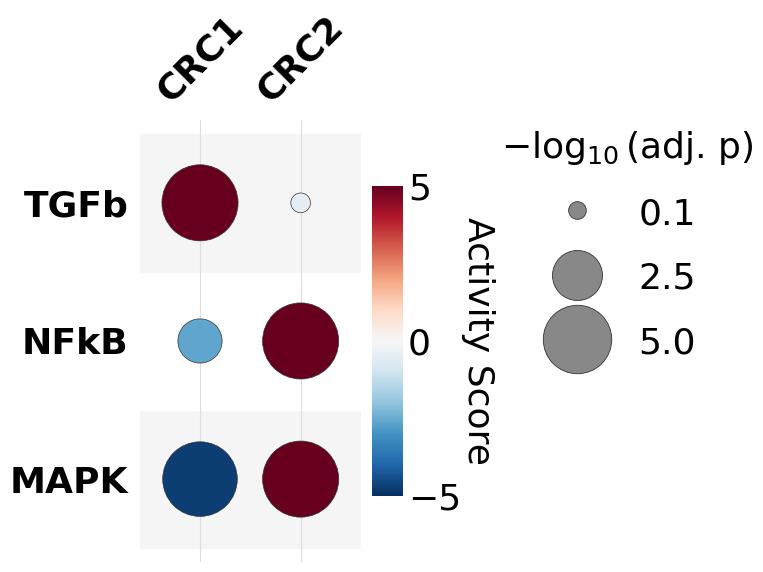

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import seaborn as sns

# ── Selection ──────────────────────────────────────────────
MODULES  = ['CRC1', 'CRC2']
PATHWAYS = ['TGFb', 'NFkB', 'MAPK']
CLIP     = 5
# ──────────────────────────────────────────────────────────

plt.rcParams.update({
    'font.family':    'sans-serif',
    'font.monospace': ['Courier New', 'DejaVu Sans Mono'],
    'font.size':       16,
})

df = pw_joint[
    pw_joint['Pathway'].isin(PATHWAYS) &
    pw_joint['Module'].isin(MODULES)
].copy()

df['Activity_clipped'] = df['Activity'].clip(-CLIP, CLIP)
df['neg_log10_padj']   = -np.log10(df['padj'].clip(lower=1e-5))

pathway_order = PATHWAYS[::-1]
module_order  = MODULES
df['x'] = df['Module'].map({m: i for i, m in enumerate(module_order)})
df['y'] = df['Pathway'].map({p: i for i, p in enumerate(pathway_order)})

# ── Size scaling ───────────────────────────────────────────
MAX_SIZE, MIN_SIZE = 3000, 200
sig_min, sig_max = df['neg_log10_padj'].min(), df['neg_log10_padj'].max()
size_range = sig_max - sig_min or 1
dot_sizes = MIN_SIZE + (df['neg_log10_padj'] - sig_min) / size_range * (MAX_SIZE - MIN_SIZE)

# ── Figure ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

for i in range(len(pathway_order)):
    ax.axhspan(i - 0.5, i + 0.5,
               color='#f5f5f5' if i % 2 == 0 else 'white', zorder=0)
for xi in range(len(module_order)):
    ax.axvline(xi, color='#dddddd', linewidth=0.8, zorder=1)

norm = mcolors.TwoSlopeNorm(vmin=-CLIP, vcenter=0, vmax=CLIP)
xx = ax.scatter(
    df['x'], df['y'],
    c=df['Activity_clipped'], s=dot_sizes,
    cmap='RdBu_r', norm=norm,
    edgecolors='#333333', linewidths=0.5,
    zorder=3,
)

ax.set_xticks(range(len(module_order)))
ax.set_yticks(range(len(pathway_order)))
ax.set_xticklabels(module_order, size=26, fontweight='bold', rotation=45, ha='center', va='bottom')
ax.set_yticklabels(pathway_order, size=26, fontweight='bold', rotation=0)
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
ax.set_xlim(-0.6, len(module_order) - 0.4)
ax.set_ylim(-0.6, len(pathway_order) - 0.4)
ax.tick_params(length=0, pad=8)
sns.despine(ax=ax, left=True, bottom=True, top=True, right=True)

# ── Colorbar — bigger, more readable ──────────────────────
cbar = fig.colorbar(
    xx, ax=ax,
    shrink=0.7,       # taller bar (was 0.4)
    pad=0.04,
    aspect=10,         # chunkier/wider bar (was 10)
    ticks=[-CLIP, 0, CLIP]
)
cbar.set_label('Activity Score', labelpad=0, rotation=270,
               va='bottom', fontsize=26)
cbar.ax.tick_params(labelsize=26, length=0)
cbar.outline.set_visible(False)

# ── Size legend — spread out, no overlap ──────────────────
# Use only 3 ticks and space them at 0%, 50%, 100% of the range
sig_ticks  = np.array([sig_min,
                        sig_min + 0.5 * size_range,
                        sig_max])
size_ticks = MIN_SIZE + (sig_ticks - sig_min) / size_range * (MAX_SIZE - MIN_SIZE)

legend_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#888888', markeredgecolor='#333333',
           markeredgewidth=0.6,
           markersize=np.sqrt(s) * 0.9,  # slightly bigger markers
           label=f'{v:.1f}')
    for s, v in zip(size_ticks, sig_ticks)
]
ax.legend(
    handles=legend_handles,
    title='$-\\log_{10}$(adj. p)',
    title_fontsize=26,        # was 14
    fontsize=26,              # was 14
    bbox_to_anchor=(1.55, 1.02),
    loc='upper left',
    frameon=False,
    labelspacing=0.8,         # was 1.2 — more vertical breathing room
    handletextpad=1.2,
)

plt.tight_layout()
plt.savefig("heatmap_dotplot.svg", bbox_inches="tight", dpi=300)
plt.savefig("heatmap_dotplot.pdf", bbox_inches="tight", dpi=300)
plt.show()

# Pathway-based perturbations

In [27]:
is_celltype1 = "Fibroblast"   # CRC1 perturbation
is_celltype2 = "Fibroblast"      # CRC2 perturbation


In [28]:
adata_pert     = results[is_celltype1].copy()
adata_ct2_pert = results[is_celltype2].copy()

In [29]:
for _ap in [adata_pert, adata_ct2_pert]:
    _ap.obs['domain'] = _ap.obs['microenvironment']
    _ap.obs['domain'] = _ap.obs['domain'].replace({'210_REF': 'Control'})
    _ap.obs['domain'] = _ap.obs['domain'].astype('category')

/tmp/ipykernel_1036564/1005614181.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  _ap.obs['domain'] = _ap.obs['domain'].replace({'210_REF': 'Control'})
/tmp/ipykernel_1036564/1005614181.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  _ap.obs['domain'] = _ap.obs['domain'].replace({'210_REF': 'Control'})


In [30]:
print(f"{is_celltype1} domains:"); display(adata_pert.obs.domain.value_counts())
print(f"{is_celltype2} domains:"); display(adata_ct2_pert.obs.domain.value_counts())

Fibroblast domains:


domain
CRC1       34458
210_TVA     4550
CRC2        4213
Control     2456
CRC4        1733
CRC3        1125
Name: count, dtype: int64

Fibroblast domains:


domain
CRC1       34458
210_TVA     4550
CRC2        4213
Control     2456
CRC4        1733
CRC3        1125
Name: count, dtype: int64

In [31]:
for _ap in [adata_pert, adata_ct2_pert]:
    _ap.X = _ap.layers['counts'].copy()
    sc.pp.normalize_total(_ap, target_sum=1e4)
    sc.pp.log1p(_ap)

1. Microenvironment subset


In [32]:
adata.obs['microenvironment'].replace({'210_REF': 'Control'}, inplace=True)

adata_sub = adata[adata.obs['microenvironment'].isin(['Control', 'CRC1', 'CRC2'])].copy()

_, ct_logfc_df_crc1 = compute_microenv_logfc(
    adata_sub, domains_key='microenvironment', labels_key=labels_key,
    ref_label='Control', crc_label='CRC1'
)
_, ct_logfc_df_crc2 = compute_microenv_logfc(
    adata_sub, domains_key='microenvironment', labels_key=labels_key,
    ref_label='Control', crc_label='CRC2'
)


/tmp/ipykernel_1036564/3289156282.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adata.obs['microenvironment'].replace({'210_REF': 'Control'}, inplace=True)
/tmp/ipykernel_1036564/3289156282.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs['microenvironment'].replace({'210_REF': 'Control'}, inplace

In [33]:
ct_logfc_df_crc1

,CADPS,MMP9,AIF1,SLC5A9,TMEM212,AKR1B1,MXRA7,MS4A12,TRDMT1,B3GNT7,...,MEF2C,HPX,FOS,KCMF1,RSAD2,SLC24A3,KRT8,ADAM28,RAD54B,H1-5
B_cell,-0.136461,0.658663,-0.359329,-0.079603,-0.126924,-0.007415,0.062709,-0.141849,-0.104230,-0.566333,...,0.377885,0.006567,-0.512221,-0.145139,-0.426480,-0.296210,-0.235300,-0.517279,-0.225781,0.651532
Endothelial,-0.639562,0.084934,-0.548755,-1.431856,-0.359935,0.424767,-0.109431,0.254363,-0.753800,-0.673675,...,-0.139103,-0.415096,0.098162,-0.118704,-0.742048,-0.182147,-0.155199,-0.806739,-0.172870,0.928230
Epithelial,0.021618,-0.124969,-0.407815,-0.246051,-0.335872,0.145237,0.202573,-2.984318,-0.278793,-1.967614,...,-0.463302,-0.534270,-1.114950,0.009217,-0.295304,-0.469141,0.132794,-0.320961,-0.067229,1.396711
Fibroblast,-0.364610,0.111613,-0.743298,-0.456453,-0.399136,-0.305565,0.227329,-0.587023,-0.810284,-0.338604,...,-0.270972,-0.565630,-1.547117,-0.142463,-0.009012,-0.086543,-0.476967,-2.326751,-0.287046,0.618473
Mast_cell,-0.713764,0.648609,-0.986321,-0.003212,-0.857982,0.950499,-0.273486,-1.267113,-0.198683,0.819603,...,-0.415556,-1.103826,-0.217882,-0.316614,0.957770,0.279909,-0.893161,-0.584536,-0.531284,0.291857
Myeloid,0.051032,1.085844,-0.349723,-0.480664,-0.646349,0.059577,0.362717,-0.492211,-0.022121,-0.412632,...,-0.094558,-0.735309,-0.715864,-0.240487,-0.338447,-0.397885,-0.435259,-0.860786,-0.114462,0.932647
Plasma_cell,-0.167880,0.159235,-0.161047,-0.080830,-0.111505,0.061394,0.169484,-0.210586,-0.019412,-0.214390,...,-0.099736,-0.113811,-0.567997,-0.028353,-0.106039,-0.006062,-0.505152,-0.543293,-0.147913,0.339707
Smooth_muscle,-0.564570,0.048621,-0.475149,0.162402,-0.170640,0.411999,-0.370479,-0.302233,-0.476021,-0.337019,...,0.330803,-0.443131,-0.527746,-0.252912,-0.242853,-0.248403,-0.455910,-1.234251,-0.054404,0.812891
T_cell,-0.542073,-0.172378,-0.041533,-0.192772,-0.011596,0.342865,0.062202,-0.468411,-0.137822,-0.463047,...,-0.170202,-0.684451,-0.372209,0.501556,-0.304007,-0.296201,-0.563712,-0.755044,-0.235634,0.582770


2. Find pathway-defining genes

In [34]:
logfc_threshold  = 0.5
padj_threshold   = 0.1
weight_threshold = 1


In [35]:
pw_tgfb = pw_progeny[(pw_progeny.source == 'TGFb') & (pw_progeny.weight.abs() > weight_threshold)]
pw_mapk = pw_progeny[(pw_progeny.source == 'MAPK') & (pw_progeny.weight.abs() > weight_threshold)]
pw_nfkb = pw_progeny[(pw_progeny.source == 'NFkB') & (pw_progeny.weight.abs() > weight_threshold)]

print(f"TGFb targets: {len(pw_tgfb)}, MAPK targets: {len(pw_mapk)}, NFkB targets: {len(pw_nfkb)}")

TGFb targets: 1151, MAPK targets: 3240, NFkB targets: 2663


3. Build per-cell-type perturbation vectors


In [36]:
filter_by_pathway = True   # False → use all |logFC|>threshold genes per cell type
# _pw_concordant_series and _all_de_series imported from helpers (cell 1)


4. Generate counterfactual populations for each target gene set

In [37]:
logfc_sub_crc1 = build_perturbation_dict(ct_logfc_df_crc1, pw_dfs=[pw_tgfb, pw_mapk])
genes_crc1_cf  = set().union(*[set(v.index) for v in logfc_sub_crc1.values()])
print(f'CRC1: {len(logfc_sub_crc1)} cell types, {len(genes_crc1_cf)} unique genes total')
for ct, v in logfc_sub_crc1.items():
    print(f'  {ct}: {len(v)} genes')
assert len(logfc_sub_crc1) > 0, "No cell types with CRC1 perturbation genes"


CRC1: 9 cell types, 291 unique genes total
  B_cell: 17 genes
  Endothelial: 97 genes
  Epithelial: 101 genes
  Fibroblast: 92 genes
  Mast_cell: 131 genes
  Myeloid: 62 genes
  Plasma_cell: 17 genes
  Smooth_muscle: 78 genes
  T_cell: 57 genes


In [38]:
from cellina._spatial_utils import make_neighbor_perturbation

adata.X = adata.layers['counts'].copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

make_neighbor_perturbation(
    adata,
    perturbations=logfc_sub_crc1,
    groupby=labels_key,
    obsm_key_out='spatial_x_cf',
    base=np.e,
)

In [39]:
logfc_sub_crc1['Epithelial'].sort_values()

PLAC8     -3.134026
ADH1C     -2.641342
SELENOP   -2.130790
MUC4      -2.076417
BCAS1     -1.716860
             ...   
SPARC      1.629222
PHLDA1     1.767003
CEMIP      1.778784
TGFBI      2.035497
FN1        2.825305
Name: Epithelial, Length: 101, dtype: float64

In [40]:
adata.X = adata.layers['counts'].copy()

In [41]:
is_tumor_region = adata.obs[domains_key].astype(str).str.contains('CRC', regex=True)

# Control cells for each perturbation
idx_ct1_ctrl = np.where(~is_tumor_region & (adata.obs[labels_key] == is_celltype1))[0]
idx_ct2_ctrl = np.where(~is_tumor_region & (adata.obs[labels_key] == is_celltype2))[0]

print(f"Control {is_celltype1}: {len(idx_ct1_ctrl)}")
print(f"Control {is_celltype2}: {len(idx_ct2_ctrl)}")

Control Fibroblast: 7006
Control Fibroblast: 7006


In [42]:
adata_pert.uns['pert_crc1'] = model.get_perturbed_expression(
    adata,
    indices=idx_ct1_ctrl,
    batch_size=4096,
    spatial_obsm_key="spatial_x_cf",
    library_size=1e4)

In [43]:
logfc_sub_crc2 = build_perturbation_dict(ct_logfc_df_crc2, pw_dfs=[pw_nfkb, pw_mapk])
genes_crc2_cf  = set().union(*[set(v.index) for v in logfc_sub_crc2.values()])
print(f'CRC2: {len(logfc_sub_crc2)} cell types, {len(genes_crc2_cf)} unique genes total')
for ct, v in logfc_sub_crc2.items():
    print(f'  {ct}: {len(v)} genes')
assert len(logfc_sub_crc2) > 0, "No cell types with CRC2 perturbation genes"


CRC2: 9 cell types, 473 unique genes total
  B_cell: 97 genes
  Endothelial: 157 genes
  Epithelial: 149 genes
  Fibroblast: 153 genes
  Mast_cell: 229 genes
  Myeloid: 163 genes
  Plasma_cell: 79 genes
  Smooth_muscle: 173 genes
  T_cell: 105 genes


In [44]:
logfc_sub_crc2['Epithelial'].sort_values()

PLAC8      -2.622994
SELENOP    -2.099000
BCAS1      -1.939105
SELENBP1   -1.881061
SLC26A2    -1.728313
              ...   
CXCL8       1.894640
S100P       1.899974
HSPH1       1.918520
GDF15       2.182152
PHLDA1      2.487912
Name: Epithelial, Length: 149, dtype: float64

In [45]:
adata.X = adata.layers['counts'].copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

make_neighbor_perturbation(
    adata,
    perturbations=logfc_sub_crc2,
    groupby=labels_key,
    obsm_key_out='spatial_x_cf',
    base=np.e,
)

In [46]:
adata.X = adata.layers['counts'].copy()

adata_ct2_pert.uns['pert_crc2'] = model.get_perturbed_expression(
    adata,
    indices=idx_ct2_ctrl,
    batch_size=4096,
    spatial_obsm_key="spatial_x_cf",
    library_size=1e4)

In [47]:
adata[idx_ct2_ctrl].obs[labels_key]

c_1_4_1077      Fibroblast
c_1_4_1118      Fibroblast
c_1_4_1151      Fibroblast
c_1_4_1167      Fibroblast
c_1_4_1617      Fibroblast
                   ...    
c_1_210_2169    Fibroblast
c_1_210_2170    Fibroblast
c_1_210_2191    Fibroblast
c_1_210_2194    Fibroblast
c_1_210_2203    Fibroblast
Name: coarse_type, Length: 7006, dtype: category
Categories (1, object): ['Fibroblast']

5. Validate: correlation with observed CRC microenvironments

In [48]:
# CT1 control expression (actual counts, normalized)
adata_pert.X = adata_pert.layers['counts'].copy()
sc.pp.normalize_total(adata_pert, target_sum=1e4)
sc.pp.log1p(adata_pert)

mask_ctrl_ct1 = ~adata_pert.obs['domain'].str.contains('CRC')
control_ct1 = np.asarray(adata_pert.X.todense()[mask_ctrl_ct1])

In [49]:
# CRC1 target expression
mask_crc1 = adata_pert.obs['domain'].str.contains('CRC1')
target_ct1 = np.asarray(adata_pert.X.todense()[mask_crc1])

cf1 = np.log1p(adata_pert.uns['pert_crc1'])

In [50]:
pear_cf1, spear_cf1 = compute_correlations(control_ct1, target_ct1, cf1, deg=100)
print(f"CF1 ({is_celltype1}, CRC1 TGFb+MAPK)  — Pearson: {pear_cf1:.3f}, Spearman: {spear_cf1:.3f}")

CF1 (Fibroblast, CRC1 TGFb+MAPK)  — Pearson: 0.651, Spearman: 0.687


In [51]:
# CT2 control and CRC2 target expression
adata_ct2_pert.X = adata_ct2_pert.layers['counts'].copy()
sc.pp.normalize_total(adata_ct2_pert, target_sum=1e4)
sc.pp.log1p(adata_ct2_pert)

mask_ctrl_ct2 = ~adata_ct2_pert.obs['domain'].str.contains('CRC')
mask_crc2     =  adata_ct2_pert.obs['domain'].str.contains('CRC2')

control_ct2 = np.asarray(adata_ct2_pert.X.todense()[mask_ctrl_ct2])
target_ct2  = np.asarray(adata_ct2_pert.X.todense()[mask_crc2])

cf2 = np.log1p(adata_ct2_pert.uns['pert_crc2'])

In [52]:
pear_cf2, spear_cf2 = compute_correlations(control_ct2, target_ct2, cf2, deg=100)
print(f"CF2 ({is_celltype2}, CRC2 NFkB+MAPK) — Pearson: {pear_cf2:.3f}, Spearman: {spear_cf2:.3f}")

CF2 (Fibroblast, CRC2 NFkB+MAPK) — Pearson: 0.878, Spearman: 0.789


In [53]:
pert_results = {
    f'{is_celltype1} CF (CRC1)': {'pearson': pear_cf1, 'spearman': spear_cf1},
    f'{is_celltype2} CF (CRC2)': {'pearson': pear_cf2, 'spearman': spear_cf2},
}

In [54]:
lfc_cf1 = cf_logfc(adata_pert.uns['pert_crc1'],     adata.obsm['recon_x'][idx_ct1_ctrl])
lfc_cf2 = cf_logfc(adata_ct2_pert.uns['pert_crc2'], adata.obsm['recon_x'][idx_ct2_ctrl])

print(f"Genes strongly responding in CF1 (|logFC|>0.5): {(np.abs(lfc_cf1)>0.5).sum()}")
print(f"Genes strongly responding in CF2 (|logFC|>0.5): {(np.abs(lfc_cf2)>0.5).sum()}")

Genes strongly responding in CF1 (|logFC|>0.5): 164
Genes strongly responding in CF2 (|logFC|>0.5): 772


2026-06-03 20:42:09 | [WARNING] Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


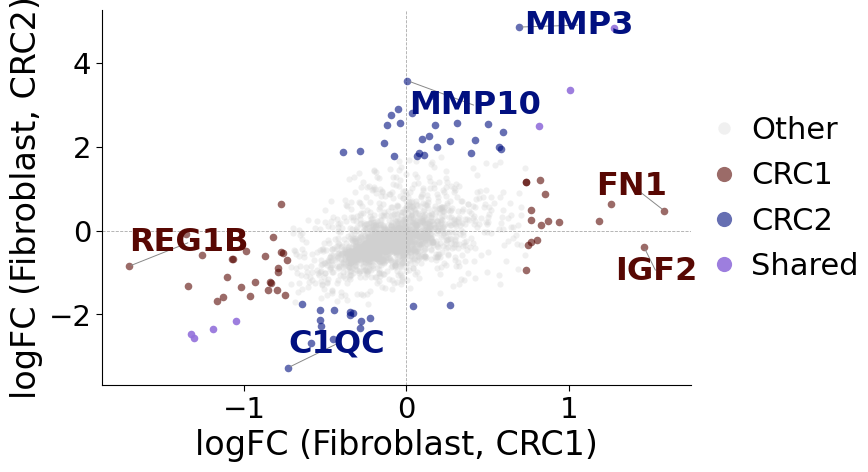

In [55]:
import matplotlib as mpl
from adjustText import adjust_text

mpl.rcParams.update({
    'font.family':       'sans-serif',
    # 'font.sans-serif':   ['Arial', 'Helvetica', 'DejaVu Sans'],
    'svg.fonttype':      'none',
    'axes.linewidth':    0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size':  4,
    'ytick.major.size':  4,
})

top_k = 50
gene_names = np.array(adata.var_names)
FS = 24

CATEGORIES = {
    'shared': dict(color='mediumpurple', label='Shared'),
    'cf1':    dict(color=palette['CRC1'], label=f'CRC1'),
    'cf2':    dict(color=palette['CRC2'], label=f'CRC2'),
}

top_cf1_genes = set(gene_names[np.argsort(-np.abs(lfc_cf1))[:top_k]])
top_cf2_genes = set(gene_names[np.argsort(-np.abs(lfc_cf2))[:top_k]])
in_top1 = np.isin(gene_names, list(top_cf1_genes))
in_top2 = np.isin(gene_names, list(top_cf2_genes))
in_both = in_top1 & in_top2

fig, ax = plt.subplots(figsize=(9, 5))

for mask, col, lbl, z, alpha, s in [
    (~in_top1 & ~in_top2, '#d0d0d0',                     'Other',                       0, 0.3, 20),
    (in_top1  & ~in_top2, CATEGORIES['cf1']['color'],    CATEGORIES['cf1']['label'],    1, 0.6, 30),
    (~in_top1 & in_top2,  CATEGORIES['cf2']['color'],    CATEGORIES['cf2']['label'],    1, 0.6, 30),
    (in_both,             CATEGORIES['shared']['color'],  CATEGORIES['shared']['label'], 2, 0.9, 30),
]:
    ax.scatter(lfc_cf1[mask], lfc_cf2[mask],
               c=col, s=s, alpha=alpha, label=lbl,
               zorder=z, linewidths=0, rasterized=True)

ax.axhline(0, color='#aaaaaa', lw=0.6, ls='--', zorder=0)
ax.axvline(0, color='#aaaaaa', lw=0.6, ls='--', zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

n_label = 3
texts = []

def label_top(mask, score, color):
    idx = np.where(mask)[0]
    top_idx = idx[np.argsort(-np.abs(score[idx]))[:n_label]]
    for i in top_idx:
        x, y = lfc_cf1[i], lfc_cf2[i]
        texts.append(ax.text(x, y, gene_names[i],
                             fontsize=FS - 1, color=color,
                             fontweight='bold', zorder=5))

# label_top(in_both,            np.abs(lfc_cf1) + np.abs(lfc_cf2), CATEGORIES['shared']['color'])
label_top(in_top1 & ~in_top2, lfc_cf1,                            CATEGORIES['cf1']['color'])
label_top(~in_top1 & in_top2, lfc_cf2,                            CATEGORIES['cf2']['color'])

adjust_text(
    texts,
    ax=ax,
    expand=(1.3, 1.6),
    arrowprops=dict(arrowstyle='-', color='#888888', lw=0.7, shrinkA=1, shrinkB=2),
    force_text=(0.6, 0.9),
    force_points=(0.4, 0.6),
)

ax.set_xlabel(f'logFC ({is_celltype1}, CRC1)', fontsize=FS)
ax.set_ylabel(f'logFC ({is_celltype2}, CRC2)', fontsize=FS)
ax.tick_params(labelsize=FS - 3)
ax.legend(
    markerscale=2,
    fontsize=FS - 2,
    loc='center left',
    bbox_to_anchor=(1.03, 0.5),
    borderaxespad=0,
    frameon=False,
    handletextpad=0.4,
    labelspacing=0.5,
)

plt.tight_layout()
fig.savefig(f'{fig_save_path}/{slide_id}_cf_lfc_scatter.svg', format='svg', bbox_inches='tight', dpi=300)
plt.show()

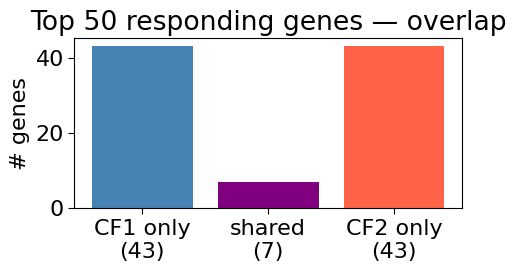

In [56]:

shared = top_cf1_genes & top_cf2_genes
fig, ax = plt.subplots(figsize=(5, 3))
counts = [len(top_cf1_genes - top_cf2_genes), len(shared), len(top_cf2_genes - top_cf1_genes)]
labels = [f'CF1 only\n({counts[0]})', f'shared\n({counts[1]})', f'CF2 only\n({counts[2]})']
ax.bar(labels, counts, color=['steelblue', 'purple', 'tomato'])
ax.set_ylabel('# genes')
ax.set_title(f'Top {top_k} responding genes — overlap')
plt.tight_layout()
plt.show()


## Systematic pathway CF correlation heatmap (all cell types × CRC1/CRC2)

In [57]:
# ── Precompute control/target mean expression for every (ct, domain) pair ─────
cell_types_sys = list(results.keys())   # Endothelial, Epithelial, Fibroblast, Myeloid, T_cell
domains_sys    = ['CRC1', 'CRC2']

ctrl_means   = {}   # ct -> mean log-normalised control expression (1-d, n_genes)
target_means = {}   # (ct, dom) -> mean log-normalised target expression

for ct in cell_types_sys:
    adata_ct = results[ct].copy()
    adata_ct.X = adata_ct.layers['counts'].copy()
    sc.pp.normalize_total(adata_ct, target_sum=1e4)
    sc.pp.log1p(adata_ct)

    X = np.asarray(adata_ct.X.todense()) if hasattr(adata_ct.X, 'todense') else np.asarray(adata_ct.X)

    mask_ctrl = ~adata_ct.obs['microenvironment'].astype(str).str.contains('CRC')
    ctrl_means[ct] = X[mask_ctrl].mean(axis=0)

    for dom in domains_sys:
        mask_tgt = adata_ct.obs['microenvironment'].astype(str) == dom
        n = int(mask_tgt.sum())
        print(f"  {ct} | {dom}: {n} target cells")
        target_means[(ct, dom)] = X[mask_tgt].mean(axis=0) if n > 0 else None

print("\nDone. Available target pairs:", [k for k, v in target_means.items() if v is not None])


  Endothelial | CRC1: 6466 target cells
  Endothelial | CRC2: 2840 target cells


  Epithelial | CRC1: 9016 target cells
  Epithelial | CRC2: 7454 target cells
  Fibroblast | CRC1: 34458 target cells
  Fibroblast | CRC2: 4213 target cells
  Myeloid | CRC1: 10109 target cells
  Myeloid | CRC2: 15671 target cells
  T_cell | CRC1: 6334 target cells
  T_cell | CRC2: 992 target cells

Done. Available target pairs: [('Endothelial', 'CRC1'), ('Endothelial', 'CRC2'), ('Epithelial', 'CRC1'), ('Epithelial', 'CRC2'), ('Fibroblast', 'CRC1'), ('Fibroblast', 'CRC2'), ('Myeloid', 'CRC1'), ('Myeloid', 'CRC2'), ('T_cell', 'CRC1'), ('T_cell', 'CRC2')]


In [58]:
# ── Systematic CF computation: one make_neighbor_perturbation call per domain ─
from cellina._spatial_utils import make_neighbor_perturbation

domains_cfg = {
    'CRC1': {'ct_logfc': ct_logfc_df_crc1, 'pw_dfs': [pw_tgfb, pw_mapk]},
    'CRC2': {'ct_logfc': ct_logfc_df_crc2, 'pw_dfs': [pw_nfkb, pw_mapk]},
}

cf_means = {}   # (ct, dom) -> mean log-normalised CF expression (1-d, n_genes)

for dom, dom_cfg in domains_cfg.items():
    logfc_sub = build_perturbation_dict(dom_cfg['ct_logfc'], pw_dfs=dom_cfg['pw_dfs'])
    print(f"\n{dom}: perturbation vectors for {list(logfc_sub.keys())}")

    # Apply neighbourhood perturbation once for this domain
    adata.X = adata.layers['counts'].copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    make_neighbor_perturbation(
        adata,
        perturbations=logfc_sub,
        groupby=labels_key,
        obsm_key_out='spatial_x_cf',
        base=np.e,
    )
    adata.X = adata.layers['counts'].copy()

    for ct in cell_types_sys:
        is_tumor = adata.obs[domains_key].astype(str).str.contains('CRC', regex=True)
        idx_ctrl = np.where(~is_tumor & (adata.obs[labels_key] == ct))[0]
        if len(idx_ctrl) == 0:
            print(f"  {ct}: no control cells — skipping")
            continue
        print(f"  {ct}: {len(idx_ctrl)} control cells → running CF")

        cf_expr = model.get_perturbed_expression(
            adata,
            indices=idx_ctrl,
            batch_size=4096,
            spatial_obsm_key='spatial_x_cf',
            library_size=1e4,
        )
        cf_means[(ct, dom)] = np.log1p(cf_expr).mean(axis=0)

print("\nCF means computed for:", list(cf_means.keys()))



CRC1: perturbation vectors for ['B_cell', 'Endothelial', 'Epithelial', 'Fibroblast', 'Mast_cell', 'Myeloid', 'Plasma_cell', 'Smooth_muscle', 'T_cell']
  Endothelial: 3024 control cells → running CF
  Epithelial: 171115 control cells → running CF
  Fibroblast: 7006 control cells → running CF
  Myeloid: 9418 control cells → running CF
  T_cell: 7284 control cells → running CF

CRC2: perturbation vectors for ['B_cell', 'Endothelial', 'Epithelial', 'Fibroblast', 'Mast_cell', 'Myeloid', 'Plasma_cell', 'Smooth_muscle', 'T_cell']
  Endothelial: 3024 control cells → running CF
  Epithelial: 171115 control cells → running CF
  Fibroblast: 7006 control cells → running CF
  Myeloid: 9418 control cells → running CF
  T_cell: 7284 control cells → running CF

CF means computed for: [('Endothelial', 'CRC1'), ('Epithelial', 'CRC1'), ('Fibroblast', 'CRC1'), ('Myeloid', 'CRC1'), ('T_cell', 'CRC1'), ('Endothelial', 'CRC2'), ('Epithelial', 'CRC2'), ('Fibroblast', 'CRC2'), ('Myeloid', 'CRC2'), ('T_cell', 